In [66]:
import matplotlib.pyplot as plt

import numpy as np
from colossus.cosmology import cosmology
cosmology.setCosmology('planck15') 
from colossus.lss import mass_function as mf 
import glob
import numexpr as ne
from scipy.optimize import newton


files = [f.split('a')[1].split('.d')[0] for f in glob.glob('ssfrs/ssfr_a*.dat')]
a_list = np.array([float(a) for a in files])
mass_list = np.array([np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,0] for f in files])
ssfr_list = [np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,1] for f in files]
    
param_file = np.loadtxt("smhm_params.txt")
names = "EFF_0 EFF_0_A EFF_0_A2 EFF_0_Z M_1 M_1_A M_1_A2 M_1_Z ALPHA ALPHA_A ALPHA_A2 ALPHA_Z BETA BETA_A BETA_Z DELTA GAMMA GAMMA_A GAMMA_Z CHI2".split(" ");
params = dict(zip(names, param_file[:,1]))

def create_ranges_numexpr(start, stop, N):

    divisor = N-1
    s0 = start[:,None]
    s1 = stop[:,None]
    r = np.arange(N)

    return ne.evaluate('((1.0/divisor) * (s1 - s0))*r + s0')

def grab_obs(redshift):
    
    obs_points = []
    with open("obs_collect.txt", 'r') as f:
        for line in f:
            if line[0:4] != ';;//':
                obs_points.append(line.split())
    x = []
    y = []
    yerr = []
    for i in obs_points:
        if float(i[0]) == redshift:
            x.append(float(i[1]))
            y.append(float(i[2]))
            yerr.append(float(i[3]))
            
    return(x,y,yerr)



class QLF():
    def __init__(self, z, bins):
        
        
        self.z = float(z)
        self.a = 1.0/(1.0+self.z)
        self.bins = bins
        self.get_zparams()
        
        self.HaloBins = np.linspace(7.0, 15.0, int((15.0 - 7.0) / self.bins))

        self.fp = self.HaloBins
        self.xp = self.get_Mstar(self.fp)
        
        self.StellBins = np.linspace(8.0, 12.2, int((12.2 - 8.0) / self.bins))
        
        
    def get_zparams(self): ##converting this to ln????
        a1 = self.a - 1.0
        lna = np.log(self.a)
        self.zparams = {}
        self.zparams['m_1'] = params['M_1'] + a1*params['M_1_A'] - lna*params['M_1_A2'] + self.z*params['M_1_Z']
        self.zparams['sm_0'] = self.zparams['m_1'] + params['EFF_0'] + a1*params['EFF_0_A'] - lna*params['EFF_0_A2'] + self.z*params['EFF_0_Z']
        self.zparams['alpha'] = params['ALPHA'] + a1*params['ALPHA_A'] - lna*params['ALPHA_A2'] + self.z*params['ALPHA_Z']
        self.zparams['beta'] = params['BETA'] + a1*params['BETA_A'] + self.z*params['BETA_Z']
        if self.zparams['beta'] < 0.05:
            self.zparams['beta'] = 0.05
        self.zparams['delta'] = params['DELTA']
        self.zparams['gamma'] = 10**(params['GAMMA'] + a1*params['GAMMA_A'] + self.z*params['GAMMA_Z'])
        
        
        
    
    def get_slope(self, logMhalo): #returns dlogMstar/dlogMhalo slope is same in log10 and ln space

        dm = logMhalo-self.zparams['m_1'];
        term1 = (self.zparams['alpha']*10.**(self.zparams['beta']*dm)+self.zparams['beta']*10.**(self.zparams['alpha']*dm))/(10.**(self.zparams['beta']*dm) + 10.**(self.zparams['alpha']*dm))
        term2 = -self.zparams['gamma']*dm*np.exp(-(dm/self.zparams['delta'])**2/2.)/self.zparams['delta']**2
        slope = term1 + term2

        return slope
    
    def get_Mstar(self,logMhalo):
    
        dm = logMhalo-self.zparams['m_1']
        dm2 = dm/self.zparams['delta']
        logMstar = self.zparams['sm_0'] - np.log10(10**(-self.zparams['alpha']*dm) + 10**(-self.zparams['beta']*dm)) + self.zparams['gamma']*np.exp(-0.5*(dm2*dm2))

        return logMstar
    
    
    def get_Mhalo(self, logMstar):
        
        logMhalo = np.interp(logMstar, self.xp, self.fp)
        
        return logMhalo
    
    
    def get_SMBM(self, dM, Mmid = 10.3, slope1 = 0.2, slope3 = 1.):

        start = [7., np.log10(1.4*10**4.)]
        stop = [12., np.log10(1.4*10**9.)]
        mstar1 = Mmid - dM
        mstar2 = Mmid + dM
        int1 = start[1] - start[0] * slope1
        int3 = stop[1] - stop[0] * slope3
        x = (int3 - int1) / (slope1 - slope3)
        y = slope1 * x + int1
        if mstar1 < x:
            mstar1 = x
        mbh1 = slope1 * mstar1 + int1
        mbh2 = mstar2 + int3
        slope2 = (mbh2 - mbh1) / (mstar2 - mstar1)
        int2 = mbh2 - mstar2 * slope2
        
        self.dM = dM

        self.slope_list, self.int_list, self.mass_cuts = [slope1, slope2, slope3], [int1, int2, int3], [mstar1, mstar2]
        
        self.early = (self.StellBins <= self.mass_cuts[0])
        self.growth = ((self.StellBins > self.mass_cuts[0]) & (self.StellBins < self.mass_cuts[1]))
        self.late = (self.StellBins > self.mass_cuts[1])
        
        self.m = self.StellBins * 0
        self.m[self.early] = self.slope_list[0]
        self.m[self.growth] = self.slope_list[1]
        self.m[self.late] = self.slope_list[2]
        
        self.b = self.StellBins * 0
        self.b[self.early] = self.int_list[0]
        self.b[self.growth] = self.int_list[1]
        self.b[self.late] = self.int_list[2]
    
    
    def gauss_array(self, vals, std):

        y = (1/np.sqrt(2.0*np.pi*std**2.0))*np.exp((-(vals[:-1]-vals[-1])**2.0)/(2.0*std**2))

        return y

    
    def convolve_smhm(self, sigma):
        
        lnten = np.log(10)
        logMh = self.get_Mhalo(self.StellBins)
        plus_mins = (7.0 * sigma)
        mins = (logMh * lnten - plus_mins)
        maxs = (logMh * lnten + plus_mins)
        mins[mins < 3 * lnten] = 3 * lnten
        maxs[maxs > 18 * lnten] = 18 * lnten
        bin_num = int(max(maxs - mins)/self.bins)
        lnMh = create_ranges_numexpr(mins, maxs, bin_num)
        dNdlnMhalo = mf.massFunction(np.e**lnMh, self.z, q_in='M', q_out='dndlnM', mdef='vir', model='despali16')
        logMstar = np.apply_along_axis(self.get_Mstar, 1, lnMh/lnten)
        vals = np.zeros((len(self.StellBins),bin_num+1))
        vals[:,-1] = self.StellBins * lnten
        vals[:,:-1] = logMstar * lnten
        Mstar_prob = np.apply_along_axis(self.gauss_array, 1, vals, sigma)
        dNdlnMstar = np.sum(Mstar_prob * dNdlnMhalo, axis = 1) * (lnMh[:,1] - lnMh[:,0])
#         for x,y in zip(logMstar,Mstar_prob):
#             plt.plot(x, y)

        return dNdlnMstar
    
    
    
    def get_dNdlnMstar(self, sig_lnMstar):
        
        if sig_lnMstar == 0.:
            self.dNdlnMstar = mf.massFunction(10.**self.get_Mhalo(self.StellBins), self.z, q_in='M', q_out='dndlnM', mdef='vir', model='despali16') / self.get_slope(self.get_Mhalo(self.StellBins))
        else:
            self.dNdlnMstar = self.convolve_smhm(sig_lnMstar)


        
    
    def get_Mdotbh(self, vals, files = files):

        Mstar = vals[0]
        slope = vals[1]
        inter = vals[2]
        lnxsig = vals[3]
        a = self.a
        Mbh = 10**(Mstar*slope+inter)
        
        
        closest_a = np.argmin(np.abs(a_list - a))
        masses = np.array(mass_list[closest_a])
        ssfrs = np.array(ssfr_list[closest_a])
        closest_m = np.argmin(np.abs(masses - Mstar))
        
        nonzero = (ssfrs != 0)
        minm = np.min(masses[nonzero])
        maxm = np.max(masses[nonzero])
        if minm < Mstar < maxm:
            ssfr = np.interp(Mstar, masses[nonzero], ssfrs[nonzero])
        else:
            ssfr = ssfr_list[closest_a][closest_m]
        
        

        Ledd = 1.3e38 * Mbh #ergs/s 
        Mdotedd = Ledd / (.1 * (2.99e10)**2) #g/s
        sbhr = slope * (ssfr / 3.154e7) #1/s
        Mdotbh = sbhr * (Mbh * 2e33) #g/s
        
        
        mu_lnX = -0.5 * lnxsig**2
        mu_lnMdotbh = mu_lnX + np.log(Mdotbh) 
        
        lnMdotsig = lnxsig
        
        return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
    
    
    def gauss_Mdot(self, lnMdotbh):
  
        x = lnMdotbh
        mu = self.Mdot_mu_sig[:,0]
        sig = self.Mdot_mu_sig[:,1]
        y = ( 1/np.sqrt(2.0 * np.pi * sig**2.0) ) * np.exp( -(x - mu)**2.0 / (2.0 * sig**2) )

        return y
    
    
    def get_dNdlnL(self, L, lnxsigs):
        
        lnxsig_list = self.StellBins * 0
        lnxsig_list[self.early] = lnxsigs[0]
        lnxsig_list[self.growth] = lnxsigs[1]
        lnxsig_list[self.late] = lnxsigs[1]
        tenper = int(0.4 * sum(self.growth))
        tranpoint = np.argmin(self.early)

        try:
            lintrans = np.linspace(lnxsigs[0], lnxsigs[1], tenper*2, endpoint = False)
            lnxsig_list[tranpoint - tenper : tranpoint + tenper] = lintrans
        except:
            lintrans = np.linspace(lnxsigs[0], lnxsigs[1], len(lnxsig_list[0 : tranpoint + tenper]), endpoint = False)
            lnxsig_list[0 : tranpoint + tenper] = lintrans
        
        
        vals = np.zeros((len(self.StellBins), 4))
        vals[:,0] = self.StellBins
        vals[:,1] = self.m
        vals[:,2] = self.b
        vals[:,3] = lnxsig_list
        self.Mdot_mu_sig = np.apply_along_axis(self.get_Mdotbh, 1, vals)
        
        self.lnMdotbh_list = (np.asarray(L) + np.log10(3.9e33)) * np.log(10) - np.log(0.1*2.99e10**2)
        
        Rl = 0.8
        Rh = 0.2
        Lc = 10**43.7
        Lx = 0.037*10**(np.asarray(L) + np.log10(3.9e33))
        self.FOb = Rl * np.e**(-Lx/Lc) + Rh * (1 - np.e**(-Lx/Lc))
        
        self.intvals = np.apply_along_axis(self.gauss_Mdot, 1, self.lnMdotbh_list.reshape(len(self.lnMdotbh_list),1)) * self.dNdlnMstar * (self.StellBins[1] - self.StellBins[0])
                                 
        self.dNdlnL = (1-self.FOb) * np.sum(self.intvals, axis = 1)

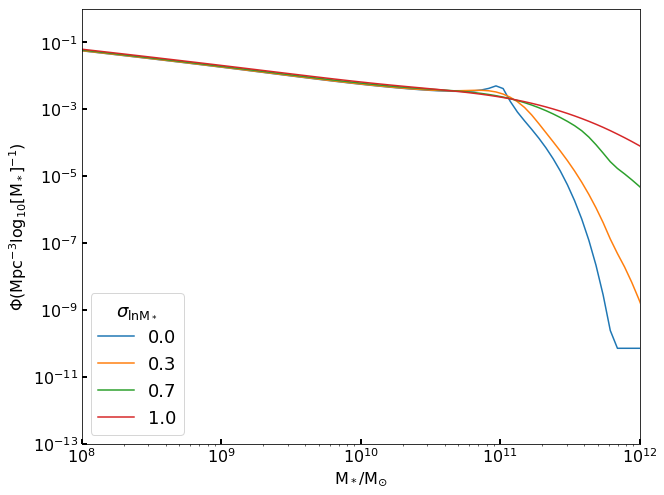

In [30]:
fig = plt.figure(figsize=(10,8))
for sigma in [0.0,0.3,0.7,1.0]:
    qlf = QLF(1.5, 0.05)
    qlf.get_dNdlnMstar(sigma)
    plt.plot(10 ** qlf.StellBins, qlf.dNdlnMstar*np.log(10), label=str(sigma))
    
leg = plt.legend(fontsize = 18, title = r'$\sigma_{\ln \rmM_*}$')
plt.xlabel(r'$\rmM_*/\rmM_{\odot}$', fontsize = 16)
plt.ylabel(r'$\Phi ($Mpc$^{-3} \log_{10} [\rmM_*]^{-1})$', fontsize =16)
plt.setp(leg.get_title(),fontsize=18)
plt.axis([10**8,10**12,10**-13,1])
plt.xscale('log')
plt.yscale('log')
plt.tick_params(direction = 'in', width = 2, length = 5, labelsize= 16)
plt.savefig('plots/paper-plots/smhm_scat_effects.pdf')

11
[6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   5.85 5.7  5.55 5.4  5.25 5.1  4.95 4.8
 4.65 4.5  4.35 4.2  4.05 3.9  3.75 3.6  3.45 3.3  3.15 3.   2.85 2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:218: RuntimeWarning: divide by zero encountered in log
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:222: RuntimeWarning: divide by zero encountered in log


11
[6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.   6.
 6.   6.   6.   6.   6.   6.   5.85 5.7  5.55 5.4  5.25 5.1  4.95 4.8
 4.65 4.5  4.35 4.2  4.05 3.9  3.75 3.6  3.45 3.3  3.15 3.   2.85 2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7  2.7
 2.7  2.7  2.7  2.7  2.

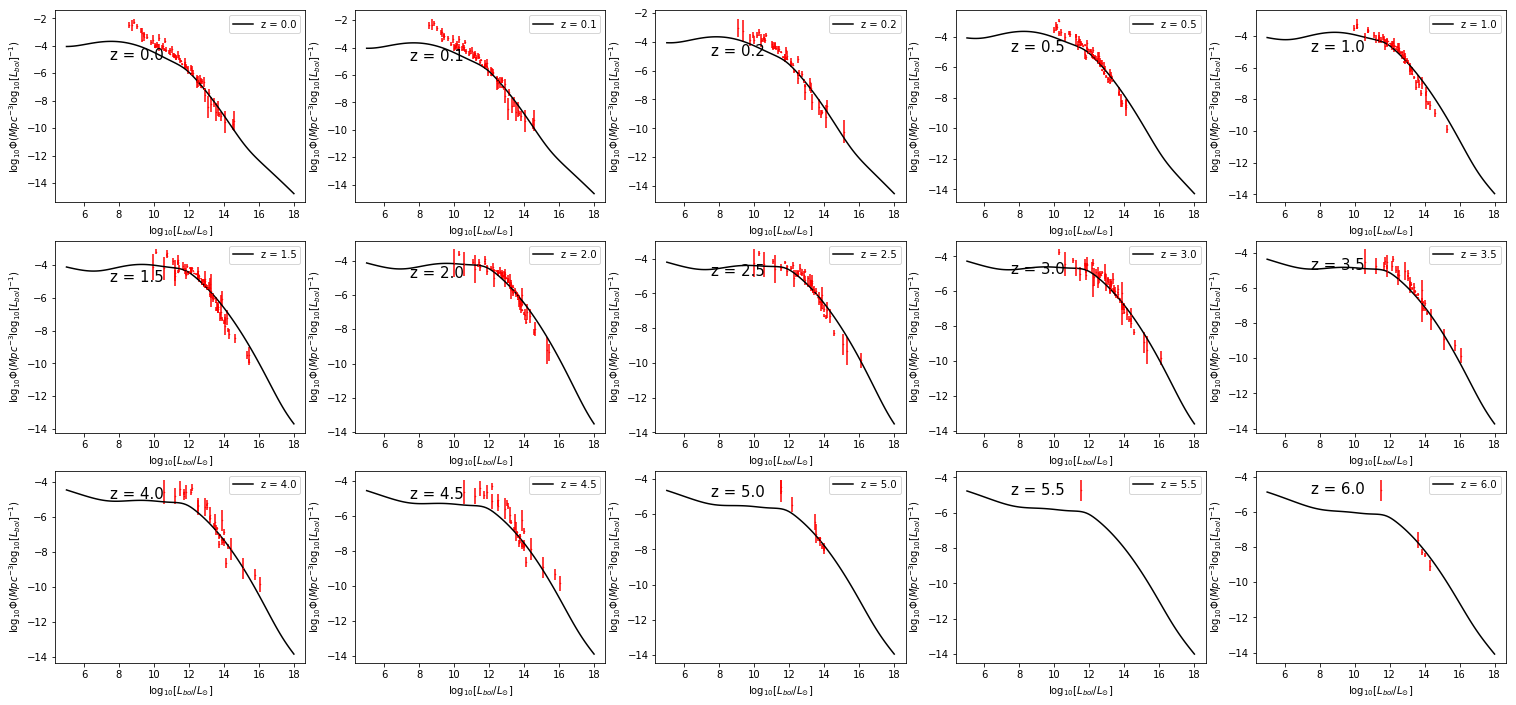

In [28]:
def get_QLF(z, lumbins, dM, bins = 0.02, sig_lnMstar = 0.7, sig_lnX = [6.0,2.7]):
    
    qlf = QLF(z, bins)
    qlf.get_dNdlnMstar(sig_lnMstar)
    qlf.get_SMBM(dM)
    qlf.LumBins = np.asarray(lumbins)
    qlf.get_dNdlnL(lumbins, sig_lnX)
    return qlf.LumBins, np.log10(qlf.dNdlnL * np.log(10))

# for z in [0.0,0.1,0.2,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0]:
#     xm, ym = get_QLF(z, np.linspace(5,18,100), 0.3)
#     plt.plot(xm, ym)

import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(26,12))
gs = gridspec.GridSpec(3, 5)
fs = 15
zlist = [0.0,0.1,0.2,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):

    xt, yt , yerr = np.array(grab_obs(z))   
    ax = fig.add_subplot(gs[i, j])
    xm, ym = get_QLF(z, np.linspace(5,18,100), 0.3)
    ax.plot(xm,ym,label='z = '+str(z),c='k')
    plt.xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$')
    plt.ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$')
    ax.text(7.5,-5,'z = '+str(z),fontsize=fs)
    ax.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='r')
    #ax.axis([7,16,-10,0])
    ax.legend()

In [67]:
%timeit get_QLF(1.5,np.linspace(5,18,500),1.3)
print()

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:218: RuntimeWarning: divide by zero encountered in log
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:222: RuntimeWarning: divide by zero encountered in log
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:230: RuntimeWarning: divide by zero encountered in true_divide
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:230: RuntimeWarning: invalid value encountered in multiply


67.2 ms ± 2.91 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

